# 🧠 Baseline Autoencoder — Masked Face Super Resolution

Premier modèle du projet. On entraîne **deux autoencodeurs identiques en parallèle**, un par tâche :
- `inpainting` : 128×128 masked → 128×128 unmasked
- `sr` : 64×64 masked → 128×128 unmasked (super-résolution 2×)

→ Comparaison finale sur PSNR / SSIM pour évaluer les performances de base avant de passer à des architectures plus complexes (U-Net, GAN, diffusion).

## Environnement
- **Kaggle Notebooks** — GPU T4 (16 GB VRAM)
- **Mixed precision (AMP)** activé → ~2× plus rapide sur T4
- **Dataset** : `splitted-masked-ffhq-cropped` (part1 + part2, 20k paires)

## Design
- **Architecture** : Autoencodeur basique avec 2 niveaux de down/up, sans skip connections.
- **SR géré par pre-upsampling bicubic** dans le modèle → même architecture pour les 2 tâches.
- **Loss** : `BaselineLoss` (L1) — pour la fidélité pixel globale.
- **Optimizer** : Adam lr=2e-4, β=(0.5, 0.999) — standard.
- **Epochs** : 10 | **Batch size** : 32

## Plan
1. Setup Kaggle + imports
2. Rechargement de l'index du notebook précédent
3. Dataset & DataLoaders (réimportés, + `num_workers=2`)
4. Architecture Autoencodeur
5. Loss L1 (BaselineLoss)
6. Métriques PSNR / SSIM
7. Boucle d'entraînement
8. Entraînement tâche `inpainting`
9. Entraînement tâche `sr`
10. Comparaison finale & visualisations
11. Sauvegarde des checkpoints
12. Synthèse

## 1. Setup Kaggle + imports

In [1]:
import os, sys, time, random, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")

PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4 (15.6 GB)


In [6]:
# ─── Paths Kaggle vs local (auto-détection robuste) ───
if Path('/kaggle/input').is_dir():
    # Chemin explicite vers le dataset Kaggle
    DATA_ROOT = Path('/kaggle/input/datasets/ikramelmenhi/dataset/dataset')
    
    # Fallback si le chemin a légèrement changé
    if not DATA_ROOT.exists():
        matches = [c.parent for c in Path('/kaggle/input').rglob('part1') if c.is_dir()]
        if len(matches) > 0:
            DATA_ROOT = matches[0]
            
    OUTPUT_DIR = Path('/kaggle/working')
else:
    # Local (ton poste)
    DATA_ROOT = next((c for c in [
        Path.cwd() / 'dataset', Path.cwd().parent / 'dataset',
        Path.cwd() / 'data' / 'raw', Path.cwd().parent / 'data' / 'raw',
    ] if c.is_dir() and (c/'part1').is_dir()), None)
    OUTPUT_DIR = Path.cwd().parent / 'src' / 'models' / 'checkpoints'

if DATA_ROOT is None or not DATA_ROOT.exists():
    raise ValueError("Dataset introuvable. Ajuste DATA_ROOT manuellement.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Vérification de la structure (on cherche 'masked' ou 'Masked')
train_dir = DATA_ROOT / 'part1' / 'train'
assert (train_dir / 'masked').is_dir() or (train_dir / 'Masked').is_dir(), \
    f"Structure inattendue dans {DATA_ROOT} — part1/train/masked manquant"

print(f"✓ DATA_ROOT  : {DATA_ROOT}")
print(f"✓ OUTPUT_DIR : {OUTPUT_DIR}")
print(f"✓ Structure validée")

✓ DATA_ROOT  : /kaggle/input/datasets/ikramelmenhi/dataset/dataset
✓ OUTPUT_DIR : /kaggle/working
✓ Structure validée


## 2. Rechargement de l'index

Si `dataset_index.csv` existe (produit par `02_preprocessing.ipynb`), on le recharge. Sinon on le reconstruit.

In [7]:
def build_index(data_dir: Path, parts, splits=('train','val','test')) -> pd.DataFrame:
    rows = []
    for part in parts:
        for split in splits:
            split_dir = data_dir / part / split
            # Gestion de la casse (masked vs Masked)
            m_dir = next((d for d in split_dir.iterdir() if d.name.lower() == 'masked' and d.is_dir()), None)
            u_dir = next((d for d in split_dir.iterdir() if d.name.lower() == 'unmasked' and d.is_dir()), None)
            
            if m_dir is None or u_dir is None: continue
            
            m = {p.name: p for p in m_dir.glob('*.png')}
            u = {p.name: p for p in u_dir.glob('*.png')}
            
            for name in sorted(set(m) & set(u)):
                rows.append({'filename': name, 'path_masked': str(m[name]),
                             'path_unmasked': str(u[name]), 'part': part, 'split': split})
    return pd.DataFrame(rows)

# Chercher l'index existant (plusieurs locations possibles)
csv_candidates = [
    Path('/kaggle/input/datasets/ikramelmenhi/dataset-index/dataset_index.csv'),
    Path('/kaggle/working/pairs_index.csv'),
    Path.cwd().parent / 'data' / 'processed' / 'pairs_index.csv',
    Path.cwd() / 'data' / 'processed' / 'pairs_index.csv',
]
idx_csv = next((c for c in csv_candidates if c.is_file()), None)

if idx_csv is not None:
    index_df = pd.read_csv(idx_csv)
    # Important : les chemins peuvent être périmés (machine différente) → on rebuild les paths
    needs_rebuild = not Path(index_df.iloc[0]['path_masked']).is_file()
    if needs_rebuild:
        print(f"⚠️ Chemins du CSV périmés → reconstruction depuis {DATA_ROOT}")
        index_df = build_index(DATA_ROOT, CONFIG['train_parts'])
    else:
        print(f"✓ Index chargé depuis {idx_csv}")
else:
    print(f"⚠️ CSV introuvable → reconstruction depuis {DATA_ROOT}")
    index_df = build_index(DATA_ROOT, CONFIG['train_parts'])

print(f"\n{len(index_df):,} paires indexées")
print(index_df.groupby(['part','split']).size().unstack(fill_value=0))

✓ Index chargé depuis /kaggle/input/datasets/ikramelmenhi/dataset-index/dataset_index.csv

20,330 paires indexées
split  test  train   val
part                    
part1  1000   8000  1000
part2  1000   8000  1000
part4    33    264    33


In [9]:
# ─── Hyperparamètres ───
CONFIG = {
    'train_parts' : ['part1', 'part2'],
    'hr_size'     : 128,
    'lr_size'     : 64,          # pour la tâche SR (2× upscaling)
    'batch_size'  : 32,
    'num_workers' : 2,
    'epochs'      : 10,
    'lr'          : 2e-4,
    'betas'       : (0.5, 0.999),
    'base_ch'     : 32,
    'use_amp'     : DEVICE.type == 'cuda',
    'val_subset'  : 500,         # images pour validation rapide en cours d'entraînement
}
for k, v in CONFIG.items():
    print(f"  {k:15} = {v}")

  train_parts     = ['part1', 'part2']
  hr_size         = 128
  lr_size         = 64
  batch_size      = 32
  num_workers     = 2
  epochs          = 10
  lr              = 0.0002
  betas           = (0.5, 0.999)
  base_ch         = 32
  use_amp         = True
  val_subset      = 500


## 3. Dataset & DataLoaders

Réimport de la classe (copie identique à `02_preprocessing`, pour que ce notebook soit autonome).

In [10]:
class MaskedFaceDataset(Dataset):
    MEAN = [0.5, 0.5, 0.5]
    STD  = [0.5, 0.5, 0.5]
    def __init__(self, df, task='inpainting', lr_size=64, hr_size=128, augment=False):
        assert task in ('inpainting','sr')
        self.df = df.reset_index(drop=True)
        self.task, self.lr_size, self.hr_size, self.augment = task, lr_size, hr_size, augment
        self._norm = transforms.Normalize(self.MEAN, self.STD)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        m = Image.open(row['path_masked']).convert('RGB')
        u = Image.open(row['path_unmasked']).convert('RGB')
        if m.size != (self.hr_size, self.hr_size): m = m.resize((self.hr_size,)*2, Image.BICUBIC)
        if u.size != (self.hr_size, self.hr_size): u = u.resize((self.hr_size,)*2, Image.BICUBIC)
        if self.augment and random.random() < 0.5:
            m = TF.hflip(m); u = TF.hflip(u)
        if self.task == 'sr':
            m = m.resize((self.lr_size,)*2, Image.BICUBIC)
        return self._norm(TF.to_tensor(m)), self._norm(TF.to_tensor(u))
    @classmethod
    def denormalize(cls, t):
        t = t.clone().cpu()
        for c, (m,s) in enumerate(zip(cls.MEAN, cls.STD)):
            (t[c] if t.ndim==3 else t[:,c]).mul_(s).add_(m)
        return t.clamp(0,1)

def build_dataloaders(index_df, task, cfg):
    loaders = {}
    for split in ['train','val','test']:
        sub = index_df[index_df['split'] == split]
        if len(sub) == 0: continue
        ds = MaskedFaceDataset(sub, task=task, lr_size=cfg['lr_size'],
                               hr_size=cfg['hr_size'], augment=(split=='train'))
        loaders[split] = DataLoader(
            ds, batch_size=cfg['batch_size'],
            shuffle=(split=='train'),
            num_workers=cfg['num_workers'],
            pin_memory=(DEVICE.type=='cuda'),
            drop_last=(split=='train'))
    return loaders

# Test quick shapes
_tmp = build_dataloaders(index_df.head(100), 'sr', CONFIG)
_xb, _yb = next(iter(_tmp['train']))
print(f"✓ SR shapes : x={tuple(_xb.shape)}  y={tuple(_yb.shape)}")
del _tmp, _xb, _yb

✓ SR shapes : x=(32, 3, 64, 64)  y=(32, 3, 128, 128)


## 4. Architecture Autoencoder

Autoencodeur basique avec 2 niveaux de down/up. Un `Upsample(scale_factor)` en amont gère la tâche SR avant compression.

In [11]:
import torch.nn as nn
import torch
class Autoencoder(nn.Module):
    """Autoencodeur simple, output tanh -> [-1,1].
    scale_factor > 1 active un pre-upsampling bicubic pour la tâche SR."""
    def __init__(self, in_ch=3, out_ch=3, base=32, scale_factor=1):
        super().__init__()
        self.pre = nn.Upsample(scale_factor=scale_factor, mode='bicubic', align_corners=False) if scale_factor > 1 else nn.Identity()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, base, 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(base, base*2, 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base*2, base, 3, 1, 1), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base, out_ch, 3, 1, 1),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.pre(x)
        return self.decoder(self.encoder(x))
# Sanity check shapes
for task, scale, in_sz in [('inpainting', 1, 128), ('sr', 2, 64)]:
    m = Autoencoder(base=CONFIG['base_ch'], scale_factor=scale).to(DEVICE)
    x = torch.randn(2, 3, in_sz, in_sz, device=DEVICE)
    with torch.no_grad():
        y = m(x)
    n_p = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"  {task:10} scale={scale}  in={tuple(x.shape)}  out={tuple(y.shape)}  params={n_p:.2f}M")
    del m, x, y


  inpainting scale=1  in=(2, 3, 128, 128)  out=(2, 3, 128, 128)  params=0.04M
  sr         scale=2  in=(2, 3, 64, 64)  out=(2, 3, 128, 128)  params=0.04M


## 5. Loss : MSE

Contrairement au U-Net (L1 + Perceptual), le baseline Autoencoder s'entraîne purement sur une Mean Squared Error (MSE).

In [12]:
import torch.nn.functional as F
class BaselineLoss(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
    def forward(self, pred, target):
        mse = F.mse_loss(pred, target)
        return mse, {'mse': mse.item()}
criterion = BaselineLoss().to(DEVICE)
print(f"✓ Baseline loss (MSE) créée")


✓ Baseline loss (MSE) créée


## 6. Métriques PSNR / SSIM

- **PSNR** (Peak Signal-to-Noise Ratio) : plus haut = mieux, typiquement 20-35 dB en reconstruction. Calculé sur `[-1,1]` donc max_val=2.
- **SSIM** (Structural Similarity) : entre 0 et 1, plus proche de 1 = mieux. Version gaussian-window 11×11.

In [13]:
@torch.no_grad()
def psnr(pred, target, max_val=2.0):
    mse = F.mse_loss(pred, target)
    if mse < 1e-10:
        return torch.tensor(100.0, device=pred.device)
    return 10 * torch.log10(max_val**2 / mse)

def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = g / g.sum()
    return (g.unsqueeze(0) * g.unsqueeze(1))

@torch.no_grad()
def ssim(pred, target, window_size=11, max_val=2.0):
    window = _gaussian_window(window_size).to(pred.device)
    window = window.unsqueeze(0).unsqueeze(0).expand(pred.size(1), 1, -1, -1)
    pad = window_size // 2
    mu1 = F.conv2d(pred, window, padding=pad, groups=pred.size(1))
    mu2 = F.conv2d(target, window, padding=pad, groups=target.size(1))
    mu1_sq, mu2_sq, mu1_mu2 = mu1*mu1, mu2*mu2, mu1*mu2
    s1 = F.conv2d(pred*pred, window, padding=pad, groups=pred.size(1)) - mu1_sq
    s2 = F.conv2d(target*target, window, padding=pad, groups=target.size(1)) - mu2_sq
    s12 = F.conv2d(pred*target, window, padding=pad, groups=pred.size(1)) - mu1_mu2
    C1, C2 = (0.01*max_val)**2, (0.03*max_val)**2
    return (((2*mu1_mu2 + C1)*(2*s12 + C2)) / ((mu1_sq + mu2_sq + C1)*(s1 + s2 + C2))).mean()

# Sanity check
a = torch.randn(2, 3, 64, 64, device=DEVICE)
b = a + 0.1 * torch.randn_like(a)
print(f"✓ PSNR perfect = {psnr(a, a).item():.2f} dB   (~100)")
print(f"✓ SSIM perfect = {ssim(a, a).item():.4f}   (~1.0)")
print(f"✓ PSNR légère perturb = {psnr(a, b).item():.2f} dB   (~26)")
print(f"✓ SSIM légère perturb = {ssim(a, b).item():.4f}    (~0.9)")

✓ PSNR perfect = 100.00 dB   (~100)
✓ SSIM perfect = 1.0000   (~1.0)
✓ PSNR légère perturb = 25.98 dB   (~26)
✓ SSIM légère perturb = 0.9393    (~0.9)


## 7. Boucle d'entraînement

Fonction unique, réutilisable pour les 2 tâches :
- Mixed precision (AMP) si CUDA
- Évaluation partielle à chaque epoch (sur `val_subset` images) pour garder le training rapide
- Sauvegarde du meilleur modèle sur val_psnr
- Logs JSON pour rejouer les courbes après coup

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, max_batches=None):
    model.eval()
    tot_loss, tot_psnr, tot_ssim, n = 0.0, 0.0, 0.0, 0
    for i, (xb, yb) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        yh = model(xb)
        loss, _ = criterion(yh, yb)
        tot_loss += loss.item() * xb.size(0)
        tot_psnr += psnr(yh, yb).item() * xb.size(0)
        tot_ssim += ssim(yh, yb).item() * xb.size(0)
        n += xb.size(0)
    return tot_loss/n, tot_psnr/n, tot_ssim/n
def train_model(task, cfg, index_df, verbose=True):
    loaders = build_dataloaders(index_df, task=task, cfg=cfg)
    scale = 2 if task == 'sr' else 1
    model = Autoencoder(base=cfg['base_ch'], scale_factor=scale).to(DEVICE)
    criterion = BaselineLoss().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], betas=cfg['betas'])
    scaler = torch.amp.GradScaler('cuda', enabled=cfg['use_amp'])
    # Pour val rapide, on crée un loader sur un subset
    val_df = index_df[index_df['split'] == 'val'].head(cfg['val_subset'])
    quick_val_ds = MaskedFaceDataset(val_df, task=task, lr_size=cfg['lr_size'],
                                     hr_size=cfg['hr_size'], augment=False)
    quick_val_loader = DataLoader(quick_val_ds, batch_size=cfg['batch_size'],
                                  num_workers=cfg['num_workers'],
                                  pin_memory=(DEVICE.type=='cuda'))
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': [], 'epoch_time': []}
    best_psnr, best_state = -float('inf'), None
    for epoch in range(1, cfg['epochs']+1):
        t0 = time.time()
        model.train()
        running = 0.0; nb = 0
        for xb, yb in loaders['train']:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=cfg['use_amp']):
                yh = model(xb)
                loss, _ = criterion(yh, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * xb.size(0); nb += xb.size(0)
        train_loss = running / nb
        val_loss, val_psnr, val_ssim = evaluate(model, quick_val_loader, criterion)
        dt = time.time() - t0
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['epoch_time'].append(dt)
        is_best = val_psnr > best_psnr
        if is_best:
            best_psnr = val_psnr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            flag = ' 🔥' if is_best else ''
            print(f"  Epoch {epoch:2d}/{cfg['epochs']}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"PSNR={val_psnr:5.2f}dB  SSIM={val_ssim:.4f}  [{dt:5.1f}s]{flag}")
    model.load_state_dict(best_state)
    return model, history
print("✓ train_model() prête")


✓ train_model() prête


## 8. Entraînement — tâche `inpainting`

128×128 masked → 128×128 unmasked. ~15 min attendues sur T4.

In [15]:
print("🎨 TÂCHE : INPAINTING\n")
model_inpaint, hist_inpaint = train_model('inpainting', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_inpaint['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_inpaint['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_inpaint['epoch_time'])/60:.1f} min")

🎨 TÂCHE : INPAINTING

  Epoch  1/10  train=0.0710  val=0.0551  PSNR=18.63dB  SSIM=0.5407  [219.7s] 🔥
  Epoch  2/10  train=0.0524  val=0.0473  PSNR=19.29dB  SSIM=0.5759  [ 63.3s] 🔥
  Epoch  3/10  train=0.0480  val=0.0464  PSNR=19.37dB  SSIM=0.5917  [ 46.7s] 🔥
  Epoch  4/10  train=0.0457  val=0.0442  PSNR=19.59dB  SSIM=0.6014  [ 41.7s] 🔥
  Epoch  5/10  train=0.0444  val=0.0418  PSNR=19.83dB  SSIM=0.6108  [ 41.4s] 🔥
  Epoch  6/10  train=0.0432  val=0.0413  PSNR=19.88dB  SSIM=0.6174  [ 40.4s] 🔥
  Epoch  7/10  train=0.0424  val=0.0414  PSNR=19.87dB  SSIM=0.6111  [ 40.2s]
  Epoch  8/10  train=0.0418  val=0.0392  PSNR=20.11dB  SSIM=0.6297  [ 40.1s] 🔥
  Epoch  9/10  train=0.0415  val=0.0390  PSNR=20.13dB  SSIM=0.6313  [ 41.0s] 🔥
  Epoch 10/10  train=0.0411  val=0.0393  PSNR=20.09dB  SSIM=0.6326  [ 40.2s]

✓ Meilleur PSNR (val) : 20.13 dB
✓ Meilleur SSIM (val) : 0.6326
✓ Durée totale        : 10.2 min


## 9. Entraînement — tâche `sr`

64×64 masked → 128×128 unmasked (super-résolution 2× + inpainting).

In [16]:
print("🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING\n")
model_sr, hist_sr = train_model('sr', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_sr['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_sr['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_sr['epoch_time'])/60:.1f} min")

🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING

  Epoch  1/10  train=0.0699  val=0.0583  PSNR=18.38dB  SSIM=0.5050  [ 57.8s] 🔥
  Epoch  2/10  train=0.0541  val=0.0505  PSNR=19.01dB  SSIM=0.5671  [ 41.4s] 🔥
  Epoch  3/10  train=0.0503  val=0.0481  PSNR=19.22dB  SSIM=0.5626  [ 41.2s] 🔥
  Epoch  4/10  train=0.0479  val=0.0495  PSNR=19.10dB  SSIM=0.5546  [ 41.2s]
  Epoch  5/10  train=0.0464  val=0.0444  PSNR=19.57dB  SSIM=0.5806  [ 40.8s] 🔥
  Epoch  6/10  train=0.0453  val=0.0457  PSNR=19.45dB  SSIM=0.5773  [ 40.9s]
  Epoch  7/10  train=0.0447  val=0.0446  PSNR=19.55dB  SSIM=0.6034  [ 40.8s]
  Epoch  8/10  train=0.0439  val=0.0422  PSNR=19.79dB  SSIM=0.6114  [ 40.9s] 🔥
  Epoch  9/10  train=0.0434  val=0.0406  PSNR=19.96dB  SSIM=0.6217  [ 41.7s] 🔥
  Epoch 10/10  train=0.0430  val=0.0433  PSNR=19.68dB  SSIM=0.6032  [ 42.1s]

✓ Meilleur PSNR (val) : 19.96 dB
✓ Meilleur SSIM (val) : 0.6217
✓ Durée totale        : 7.1 min


## 10. Comparaison finale & visualisations

Évaluation **sur le test set complet** (2 000 images jamais vues) pour chaque modèle, plus visualisation côte-à-côte de prédictions.

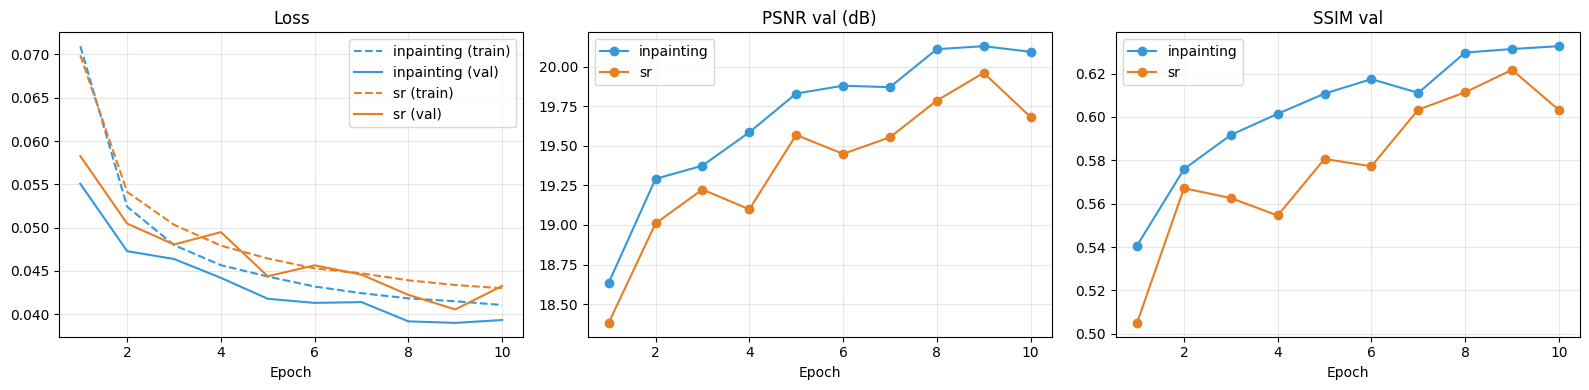

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, hist, color in [('inpainting', hist_inpaint, '#3498db'), ('sr', hist_sr, '#e67e22')]:
    axes[0].plot(hist['epoch'], hist['train_loss'], label=f'{name} (train)', color=color, linestyle='--')
    axes[0].plot(hist['epoch'], hist['val_loss'],   label=f'{name} (val)',   color=color)
    axes[1].plot(hist['epoch'], hist['val_psnr'], label=name, color=color, marker='o')
    axes[2].plot(hist['epoch'], hist['val_ssim'], label=name, color=color, marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('PSNR val (dB)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title('SSIM val'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
# Évaluation sur le test complet
criterion = BaselineLoss().to(DEVICE)

test_results = {}
for task, model in [('inpainting', model_inpaint), ('sr', model_sr)]:
    loaders = build_dataloaders(index_df, task=task, cfg=CONFIG)
    loss, p, s = evaluate(model, loaders['test'], criterion)
    test_results[task] = {'loss': loss, 'psnr': p, 'ssim': s}
    print(f"  {task:10} | loss={loss:.4f}  PSNR={p:.2f}dB  SSIM={s:.4f}")

df_res = pd.DataFrame(test_results).T
df_res.columns = ['Test Loss', 'Test PSNR (dB)', 'Test SSIM']
print("\n📊 Résultats sur le test set (2 000 images) :")
print(df_res.round(4).to_string())

  inpainting | loss=0.0413  PSNR=19.97dB  SSIM=0.6285
  sr         | loss=0.0428  PSNR=19.81dB  SSIM=0.6191

📊 Résultats sur le test set (2 000 images) :
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.0413          19.973     0.6285
sr             0.0428          19.814     0.6191


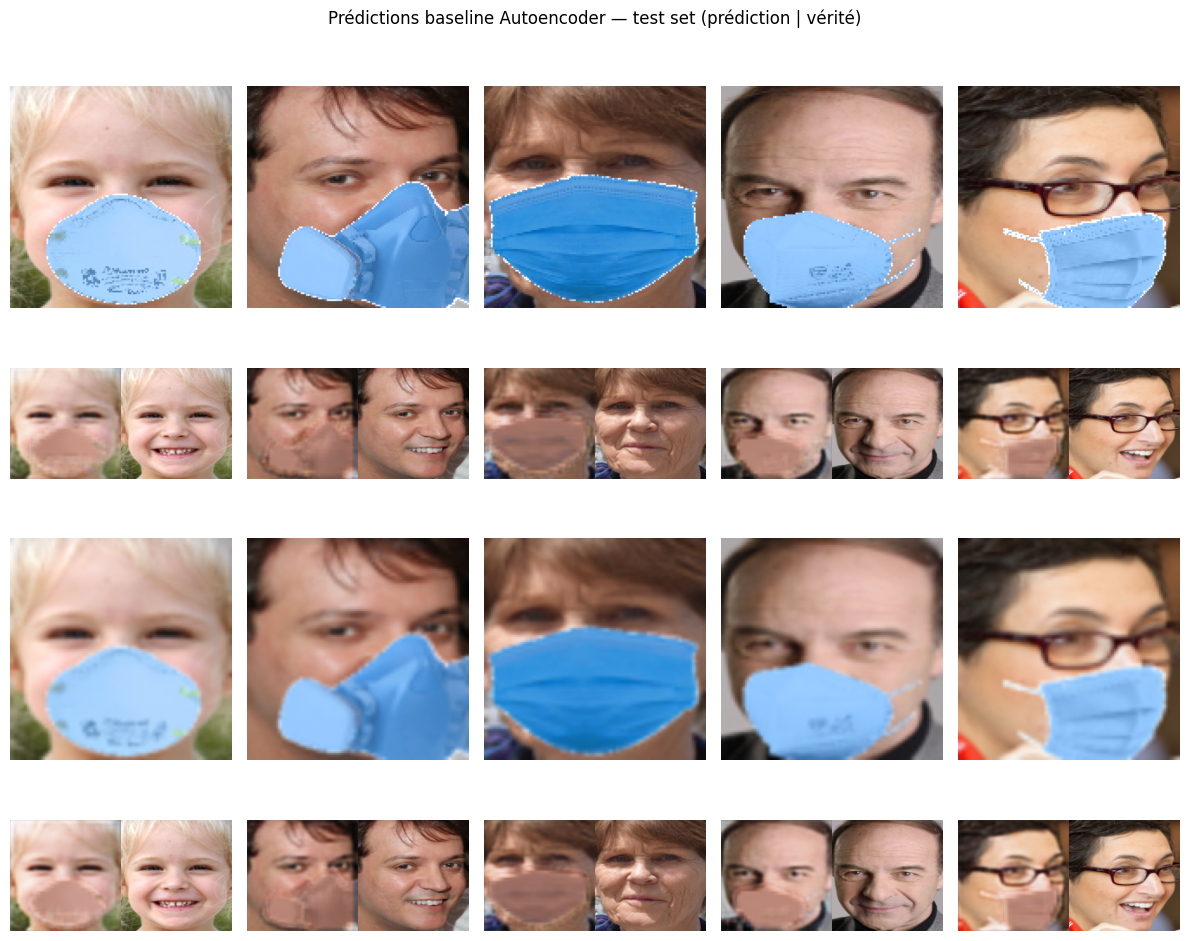

In [19]:
# Visualisation qualitative : 5 exemples du test set par tâche
def to_plot(t):
    return MaskedFaceDataset.denormalize(t).permute(1,2,0).numpy()
n_show = 5
fig, axes = plt.subplots(4, n_show, figsize=(2.4*n_show, 10))
for row_task, (task, model) in enumerate([('inpainting', model_inpaint), ('sr', model_sr)]):
    test_df = index_df[index_df['split']=='test'].sample(n_show, random_state=SEED).reset_index(drop=True)
    ds = MaskedFaceDataset(test_df, task=task, lr_size=CONFIG['lr_size'], hr_size=CONFIG['hr_size'])
    model.eval()
    with torch.no_grad():
        for i in range(n_show):
            x, y = ds[i]
            yh = model(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
            r_in = row_task * 2
            r_pred = row_task * 2 + 1
            # Si SR, on upsample l'input pour affichage cohérent
            x_show = TF.resize(x, [CONFIG['hr_size']]*2, antialias=True) if task=='sr' else x
            axes[r_in, i].imshow(to_plot(x_show)); axes[r_in, i].axis('off')
            axes[r_pred, i].imshow(np.concatenate([to_plot(yh), to_plot(y)], axis=1))
            axes[r_pred, i].axis('off')
            if i == 0:
                axes[r_in, i].set_ylabel(f'{task}\ninput', rotation=0, labelpad=40, fontsize=10)
                axes[r_pred, i].set_ylabel(f'{task}\npred | target', rotation=0, labelpad=40, fontsize=10)
plt.suptitle('Prédictions baseline Autoencoder — test set (prédiction | vérité)', y=1.01)
plt.tight_layout(); plt.show()


## 11. Sauvegarde des checkpoints

Les poids + la config + l'historique pour pouvoir reprendre ou évaluer plus tard sans ré-entraîner.

In [20]:
for task, model, hist in [('inpainting', model_inpaint, hist_inpaint),
                           ('sr',        model_sr,      hist_sr)]:
    ckpt_path = OUTPUT_DIR / f'autoencoder_{task}_best.pt'
    torch.save({
        'task'    : task,
        'config'  : CONFIG,
        'state'   : model.state_dict(),
        'history' : hist,
        'test'    : test_results[task],
    }, ckpt_path)
    size_mb = ckpt_path.stat().st_size / 1e6
    print(f"✓ {ckpt_path.name} sauvé ({size_mb:.1f} MB)")
# Historique combiné en JSON (léger, lisible)
with open(OUTPUT_DIR / 'training_summary.json', 'w') as f:
    json.dump({
        'config'  : CONFIG,
        'inpainting': {'history': hist_inpaint, 'test': test_results['inpainting']},
        'sr'      : {'history': hist_sr,      'test': test_results['sr']},
    }, f, indent=2, default=str)
print(f"✓ training_summary.json sauvé")


✓ autoencoder_inpainting_best.pt sauvé (0.2 MB)
✓ autoencoder_sr_best.pt sauvé (0.2 MB)
✓ training_summary.json sauvé


In [21]:
print("="*65)
print("📋 BASELINE AUTOENCODER — RÉSULTATS")
print("="*65)
print(f"\n▸ Config : {CONFIG['epochs']} epochs, batch={CONFIG['batch_size']}, lr={CONFIG['lr']}")
print(f"▸ Paires train/val/test : {(index_df['split']=='train').sum():,} / {(index_df['split']=='val').sum():,} / {(index_df['split']=='test').sum():,}")
print(f"\n▸ RÉSULTATS TEST SET")
print(df_res.round(4).to_string())
# Diagnostic
inp_psnr, sr_psnr = test_results['inpainting']['psnr'], test_results['sr']['psnr']
inp_ssim, sr_ssim = test_results['inpainting']['ssim'], test_results['sr']['ssim']
print(f"\n▸ INTERPRÉTATION")
if inp_psnr > sr_psnr + 1:
    print(f"   • Inpainting > SR de {inp_psnr-sr_psnr:.2f} dB — attendu (SR a la tâche supplémentaire du 2× upscaling)")
elif sr_psnr > inp_psnr + 1:
    print(f"   • SR > inpainting de {sr_psnr-inp_psnr:.2f} dB — surprenant, à investiguer")
else:
    print(f"   • Performances comparables (écart {abs(inp_psnr-sr_psnr):.2f} dB)")
if inp_psnr < 22:
    print("   ⚠️  PSNR faible → le modèle sous-apprend. Pistes : +epochs, +capacité, loss plus agressive")
elif inp_psnr < 28:
    print("   ✓ PSNR correct pour un baseline — marge nette pour GAN/diffusion")
else:
    print("   ✓ PSNR élevé — le baseline est solide, GAN apportera surtout du réalisme perceptuel")
print(f"\n▸ PROCHAINES ÉTAPES POSSIBLES")
print("   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)")
print("   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent")
print("   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations")


📋 BASELINE AUTOENCODER — RÉSULTATS

▸ Config : 10 epochs, batch=32, lr=0.0002
▸ Paires train/val/test : 16,264 / 2,033 / 2,033

▸ RÉSULTATS TEST SET
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.0413          19.973     0.6285
sr             0.0428          19.814     0.6191

▸ INTERPRÉTATION
   • Performances comparables (écart 0.16 dB)
   ⚠️  PSNR faible → le modèle sous-apprend. Pistes : +epochs, +capacité, loss plus agressive

▸ PROCHAINES ÉTAPES POSSIBLES
   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)
   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent
   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations
